#### Support Vector Machine (SVM) 
- It maximizes the margin between the decision boundary and training data points.
- The margin is defined as the distance between the separating hyperplane (decision boundary) and the training examples that are closes to this hyperplane. Those trainining samples are called support vectors. \
<img src="images/svm.png" width=500>
- Perceptron fits training data agressively, so it tends to overfit and generalize poorly.
- Adaine use MSE to create a soft boundary, which reduces overfitting and generalize better than Perceptron.
- SVM maximizes the margin, pushing the hyperplane away from both classes -> max-margin acts as implicite regularization. SVM finds the unique solution and guarantee the strongest generalization between these 3.
- **C** is a hyperparameter controlling the penalty for misclassification. Large **C** -> more penalty for misclassification -> overfitting. \
<img src="images/svm_with_c_penalty.png" width=400>

In [2]:
from sklearn.svm import SVC
from classification_algos.make_data import generate_iris_data
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = generate_iris_data(num_class="multi")
X_train_2_features = X_train[:, :2]
X_test_2_features = X_test[:, :2]
model = SVC()
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [4]:
preds = model.predict(X_test)
accuracy = accuracy_score(preds, y_test)
print(accuracy)

0.9333333333333333


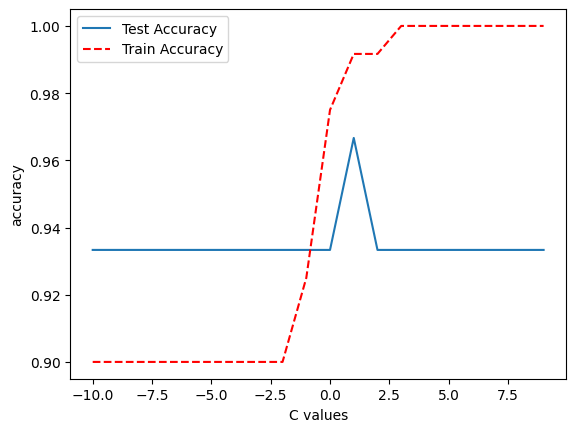

In [13]:
# try some different C values
import numpy as np
C_params = []
test_accuracies = []
train_accuracies = []

for c in np.arange(-10, 10):
    model = SVC(C=10.**c)
    model.fit(X_train, y_train)
    # test accuracies
    preds = model.predict(X_test)
    accuracy = accuracy_score(preds, y_test)
    C_params.append(c)
    test_accuracies.append(accuracy)
    # train accuracies
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(train_preds, y_train)
    train_accuracies.append(train_accuracy)

# plot
import matplotlib.pyplot as plt

plt.plot(C_params, test_accuracies, label="Test Accuracy")
plt.plot(C_params, train_accuracies, linestyle="--", color="red", label="Train Accuracy")
plt.xlabel("C values")
plt.ylabel("accuracy")
plt.legend()
plt.show()

#### when C increases, it starts to overfit, but the test accuracies doesn't improve. 